# **Topics and trends discovery module**

 - 0. Introduction
 - 1. Gathering data & dataset analysis
   - a. An initial look at the data
   - b. Parse data
   - c. Save Dataset to Pandas Dataframe
- 2. Data Science  
  - a. The difference in Computer Science research topics per decade - Clustering
  - b. Smart topic recommendation using emmbeding

## 0. Introduction

This project is focused on analizing the biggest available dataset about Computer Science Papers. My main goal is to extract the most interesting information and use best fit of AI/ML models for this problem.

In this first module called "Topics and trends discovery" I'm going to anlyze reseacrh papers topics trends during three decades - 2004, 2014 and 2024.

`You will find various notes interspersed throughout the text, detailing my thought process and the challenges I encountered during the project` - all conflicts, troubleshooting, reflections, some knowledge from my experience and other. I encourage you to read them. I also hope my comments are clear and understandable - sorry for any typos but I've probably wrote this at night! :)

In [ ]:
# Frameworks
from lxml import etree
import numpy as np
import pandas as pd
from data_analysis_helper import DataAnalysisHelper
from sentence_transformers import SentenceTransformer 
from umap import UMAP
import matplotlib.pyplot as plt 
from hdbscan import HDBSCAN 
from bertopic import BERTopic
from transformers import pipeline 
from bertopic.representation import TextGeneration 
import seaborn as sns

## 1. Dataset analysis

One of most crucial steps in Data Science is to fully understand the concept. Therefore, my first priority will be to analyze the dataset structure

For xml file read I've decided to use lxml library, because it's more time efficient than a standard Python library for *.xml.

### An initial look at the data
Based on the dblp.dtd, the available XML tags are as follows:


main:
- `article` - artykuł naukowy opublikowany w czasopiśmie
- `inproceedings` - artykuł w materiałach konferencyjnych
- `proceedings` - całe materiały konferencyjne (zbiór artykułów)
- `book` - książka (monografia)
- `incollection` - rozdział w książce lub pracy zbiorowej
- `phdthesis` - rozprawa doktorska
- `mastersthesis` - praca magisterska
- `www` - zasób internetowy (np. strona WWW)
- `person` - informacja o osobie (np. autorze)
- `data` - zbiór danych lub dataset

Parameter Entity:
- `author` - autor publikacji
- `editor` - redaktor (np. książki lub materiałów konferencyjnych)
- `title` - tytuł publikacji
- `booktitle` - tytuł książki lub konferencji, w której opublikowano pracę
- `pages` - zakres stron
- `year` - rok publikacji
- `address` - miejsce wydania (np. miasto)
- `journal` - nazwa czasopisma
- `volume` - numer tomu
- `number` - numer wydania w ramach tomu
- `month` - miesiąc publikacji
- `url` - link do publikacji
- `ee` - link do wersji elektronicznej (electronic edition)
- `cdrom` - lokalizacja wersji na nośniku CD-ROM
- `cite` - odwołanie do innej publikacji
- `publisher` - wydawnictwo
- `note` - dodatkowe informacje
- `crossref` - odwołanie do innego wpisu (np. konferencji)
- `isbn` - numer ISBN książki
- `series` - seria wydawnicza
- `school` - uczelnia (dla prac dyplomowych)
- `chapter` - numer rozdziału
- `publnr` - numer publikacji (np. raportu technicznego)
- `stream` - strumień lub kategoria publikacji
- `rel` - relacja z innymi wpisami

### Parse data
from *.xml file

My first idea was to pick 100 papaers from every month from every year. By this method, our data would be heterogeneous and representative. However, results in tests showed that there're not enough labaled 'month' tags for later unsupervised clustering implementation. Because of that, I needed to pick the total value, without breakdown by months.

In [ ]:
# Important sets, lists and path
all_top_tags = {"article", "inproceedings", "proceedings", "book", 
                        "incollection", "phdthesis", "mastersthesis", "www", "person", "data"}

year_range = ["2004", "2014", "2024"]

xml_path = r"C:\Users\wikto\OneDrive\Dokumenty\all-datasets\dblp-dataset\dblp.xml"

# Initialize the helper class and call the method within to
# Extract publication data filtered by the specified year range
helper_class = DataAnalysisHelper(xml_path, all_top_tags)
publications = helper_class.parse_publications(year_range)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wikto\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Limit reached for 2024....
Limit reached for 2014....
Limit reached for 2004....
Limit reached for every year. Ending....


### Save Dataset to Pandas Dataframe

In [ ]:
flatted_data = []
for year, records in publications.items():
    for record in records:
        flatted_data.append({
            "Year": year,
            "Type": record["type"],      
            "Author": record["author"],  
            "Title": record["title"],    
            "Journal": record["journal"],
            "Booktitle": record["booktitle"],
            "Address": record["address"],
            "Month": record["month"]
        })

df = pd.DataFrame(flatted_data)

In [ ]:
# Look on main dataset
df.head()

,Year,Type,Author,Title,Journal,Booktitle,Address,Month
0,2004,book,Jeremy J. Ramsden,Bioinformatics: An Introduction,None,None,None,None
1,2004,book,None,Artificial Intelligence Methods And Tools For ...,None,None,None,None
2,2004,book,None,The Rise of Modern Logic: From Leibniz to Frege,None,None,None,None
3,2004,book,None,"Greek, Indian and Arabic Logic",None,None,None,None
4,2004,book,Klaus Schneider 0001,Verification of Reactive Systems - Formal Meth...,None,None,None,None


## 2. Data Science

### The difference in Computer Science research topics per decadeusing unsupervised methods
In this section, I will analyze the evolution of research topics across three decades. Since the dataset is unlabeled, classic supervised learning is not an option unless I were to label the samples manually. For this, I'm going to use NLP and clustering techniques.

1. `Preprocess` - of course, computer is a binary machine that doesn't understand a concept of words as letters. That's why it's important to change words to vector float representation. For this, data needs to be clean - with no upperletters, stopwords or other type of noise.
2. `Embedding` - as I've said, we need numeric representetion of words. Embedding is a method that changes words to numbers, and represents them in high dimension. For example, words like "cat" and "dog" are going to be closer to each other than "car".
3. `Reduce the dimensionality` - we can not see in more than third dimension, that's why in unsupervised learning we use methods like **PCA, UMAP or t-SNE** to reduce the dimension. This is particularly important for visualizing clusters of semantically similar words.
4. `Cluster` -
5. `Plot` - 

Preprocess data

In [ ]:
# Preprocess data for NLP ready usage
prepared_titles = helper_class.preprocess_for_nlp(df, "Title")
prepared_titles


0                          [bioinformatics, introduction]
1       [artificial, intelligence, methods, tools, sys...
2                   [rise, modern, logic, leibniz, frege]
3                          [greek, indian, arabic, logic]
4       [verification, reactive, systems, formal, meth...
                              ...                        
3595    [large, language, models, good, emotional, sup...
3596    [analyze, generate, refine, query, expansion, ...
3597    [llmsdriven, synthetic, data, generation, cura...
3598    [comprehensive, study, jailbreak, attack, vers...
3599    [perturbed, examples, reveal, invariances, sha...
Name: Title, Length: 3600, dtype: object

Embedding

In [ ]:
# Embedding

# ! ! For now I use gte model - which has it's own tokenize methold build within. ! !
# ! ! That's why I don't use preprocessed titles. ! !
only_titles = df['Title']
only_titles = only_titles.str.lower()

'''Code below is commented out to prevent downloading'''
# !! I use multiligual model - there're many languages in dataset !!

#texts_to_encode_for_e5 = ("passage: " + only_titles).tolist() # Perifix is necessary for e5 models

embedding_model = SentenceTransformer('intfloat/multilingual-e5-small') 
#embeddings = embedding_model.encode(texts_to_encode_for_e5, show_progress_bar=True, normalize_embeddings=True)

# !! Save embeddings !!
#np.save('data/dblp_embeddings.npy', embeddings)


In [ ]:

# Load embeddings - for now, easy numpy (bc I want plot some correlations)
# For RAG and smart searchers i would to use vector databases like ChromaDB (which I use in my second module)

embeddings = np.load(r"C:\Users\wikto\OneDrive\Dokumenty\AA_projects\DBLP-dataset-analysis\data\dblp_embeddings_gte_small.npy")



Reduce dimensionality

In [ ]:
# Reduce dimensionality for visualization and clustering
# I’ll use UMAP as it tends to handle nonlinear relationships better

umap_reduce = UMAP(n_components=2, min_dist=0.0, metric='cosine', random_state=123)
reduced_embeddings = umap_reduce.fit_transform(embeddings)

# Important! UMAP and every dimensionality reducing algorithm can cause information loss.

Cluster

In [231]:
# Clustering using density-based algorithms
# those algorithms calculate the number of clusters freely and do not force all points into a cluster.
# We’ll use HDBSCAN for our case.

hdbscan_model = HDBSCAN(min_cluster_size=35, metric="euclidean", cluster_selection_method="eom",
                        prediction_data=True).fit(reduced_embeddings)
clusters = hdbscan_model.labels_



Plot data

(np.float64(-0.43790644221007824),
 np.float64(10.951829737052321),
 np.float64(-0.7707791343331337),
 np.float64(6.042979808151722))

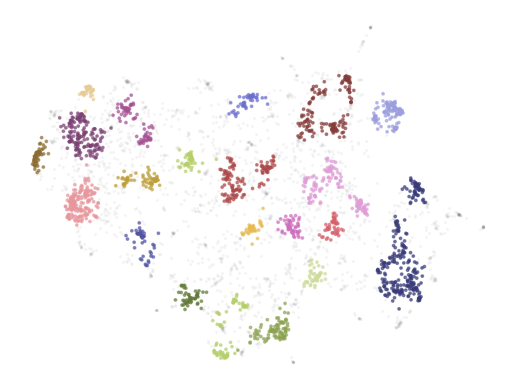

In [233]:
# Plot data

df_clusters = pd.DataFrame(reduced_embeddings, columns=["x1", "x2"])
df_clusters["title"] = only_titles
df_clusters["cluster"] = [str(c) for c in clusters] 

# Outliers and non outliers
to_plot = df_clusters.loc[df_clusters.cluster != "-1", :] 
outliers = df_clusters.loc[df_clusters.cluster == "-1", :]

plt.scatter(outliers.x1, outliers.x2, alpha=0.05, s=2, c="grey") 
plt.scatter(to_plot.x1, to_plot.x2, c=to_plot.cluster.astype(int), alpha=0.6, s=3, cmap="tab20b" ) 
plt.axis("off")

Statistics - charts, analyze popularity

In [232]:
# Statistics
df_year_titles = df[['Year', 'Title']]
df_with_clusters = df_year_titles.join(df_clusters)

df_with_clusters
df_without_noise = df_with_clusters[df_with_clusters['cluster'] != "-1"]
df_without_noise['cluster'] = df_without_noise['cluster'].astype(int)

df_without_noise_n = df_without_noise

In [ ]:
unique, counts = np.unique(clusters, return_counts=True)
cluster_stats = dict(zip(unique, counts))

print("Claster statistics:")
print(cluster_stats)

# Clusters with class "-1" are classified as noise
print(sorted(cluster_stats.values()))

Claster statistics:
{np.int64(-1): np.int64(1700), np.int64(0): np.int64(53), np.int64(1): np.int64(214), np.int64(2): np.int64(47), np.int64(3): np.int64(47), np.int64(4): np.int64(115), np.int64(5): np.int64(51), np.int64(6): np.int64(89), np.int64(7): np.int64(72), np.int64(8): np.int64(44), np.int64(9): np.int64(49), np.int64(10): np.int64(66), np.int64(11): np.int64(63), np.int64(12): np.int64(35), np.int64(13): np.int64(42), np.int64(14): np.int64(142), np.int64(15): np.int64(83), np.int64(16): np.int64(42), np.int64(17): np.int64(48), np.int64(18): np.int64(166), np.int64(19): np.int64(159), np.int64(20): np.int64(82), np.int64(21): np.int64(55), np.int64(22): np.int64(47), np.int64(23): np.int64(89)}
[np.int64(35), np.int64(42), np.int64(42), np.int64(44), np.int64(47), np.int64(47), np.int64(47), np.int64(48), np.int64(49), np.int64(51), np.int64(53), np.int64(55), np.int64(63), np.int64(66), np.int64(72), np.int64(82), np.int64(83), np.int64(89), np.int64(89), np.int64(115), 

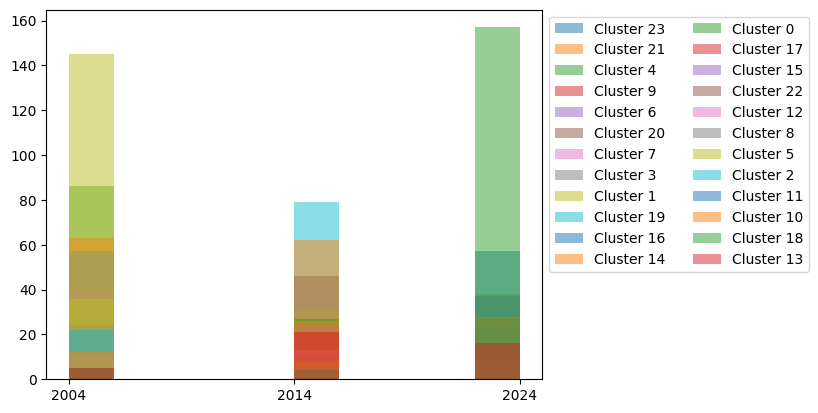

In [171]:
for cluster_id in df_without_noise["cluster"].unique():
    subset = df_without_noise[df_without_noise["cluster"] == cluster_id]
    plt.hist(subset["Year"], alpha=0.5, label=f"Cluster {cluster_id}")

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=2)
plt.show()

**Simply identifying clusters by number is insufficient for a meaningful time-trend analysis. To address this, I will implement a neural network to classify and label these clusters**

Check what titles are in clusters

In [238]:
pd.set_option('display.max_colwidth', None)
print(f"Example titles for cluster 1:\n {df_without_noise['title'][df_without_noise['cluster'] == 1].iloc[:3]}")


Example titles for cluster 1:
 25    oss for telecom networks - an introduction to network management
26                        umts: origins, architecture and the standard
48                                                 cellular computing.
Name: title, dtype: object


In [239]:

print(f"Example titles for cluster 2:\n {df_without_noise['title'][df_without_noise['cluster'] == 2].iloc[:3]}")


Example titles for cluster 2:
 357    spoken dialogue technology - toward the conversational user interface.
481           from brows to trust - evaluating embodied conversational agents
531                          emotionally intelligent tutoring systems (eits).
Name: title, dtype: object


In [240]:

print(f"Example titles for cluster 4:\n {df_without_noise['title'][df_without_noise['cluster'] == 4].iloc[:3]}")

Example titles for cluster 4:
 9     software-produkt-management - nachhaltiger erfolgsfaktor bei herstellern und anwendern.
10                                     modellierung mit uml - sprache, konzepte und methodik.
11                          mobile datenbanksysteme - architektur, implementierung, konzepte.
Name: title, dtype: object


*Topic modeling approach is more probabilistic*. For example, in this approach we can classify some papper as 80% about network protocols, and other 20% about Machine Learning (for example, there was used ML algorithm for networks). It gives us more freedom - and more immportly, we can see some trend in passing years.

We use our prevoius defined pipeline - embedding, dimensionality reuction etc...
However, now we use BERTopic which automatically finds the main topics in large collections of texts. 
Once the clusters are formed, it uses a Bag-of-Words technique to treat each cluster as a single large "document". It sums each informantion in cluster into one and checks frequency of words.

In [175]:
topic_model = (BERTopic(embedding_model=embedding_model, 
                        umap_model=umap_reduce,
                        hdbscan_model=hdbscan_model,
                        verbose=True,
                        calculate_probabilities=True)
               .fit(only_titles, embeddings))

2026-04-05 22:40:36,455 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 22:41:00,722 - BERTopic - Dimensionality - Completed ✓
2026-04-05 22:41:00,737 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 22:41:01,023 - BERTopic - Cluster - Completed ✓
2026-04-05 22:41:01,023 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 22:41:01,121 - BERTopic - Representation - Completed ✓


In [176]:
pd.reset_option('display.max_colwidth')
bert_topic_df = topic_model.get_topic_info()

# First 5 classes by BERTopic
bert_topic_df.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1700,-1_and_for_of_in,"[and, for, of, in, the, based, to, on, with, d...",[multi-modal retrieval for large language mode...
1,0,214,0_networks_wireless_channel_for,"[networks, wireless, channel, for, network, pe...",[network architecture for scalable ad hoc netw...
2,1,166,1_language_models_large_multilingual,"[language, models, large, multilingual, for, i...",[cross-lingual knowledge editing in large lang...
3,2,159,2_word_semantic_natural_of,"[word, semantic, natural, of, sense, induction...",[a framework for unsupervised natural language...
4,3,142,3_software_web_ed_business,"[software, web, ed, business, the, java, cover...",[object-oriented software engineering - using ...


In [ ]:
# Plot
fig = topic_model.visualize_documents(only_titles, reduced_embeddings=reduced_embeddings, width=1200, hide_annotations=True ) 
fig.update_layout(font=dict(size=22))

Now we have base for label by LLM.

In [180]:
from bertopic.representation import MaximalMarginalRelevance 

# Update our topic representations to MaximalMarginalRelevance 
representation_model = MaximalMarginalRelevance(diversity=0.2) 
topic_model.update_topics(only_titles, representation_model=representation_model)

topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1700,-1_and_learning_analysis_systems,"[and, learning, analysis, systems, detection, ...",[multi-modal retrieval for large language mode...
1,0,214,0_networks_wireless_protocol_routing,"[networks, wireless, protocol, routing, ip, ca...",[network architecture for scalable ad hoc netw...
2,1,166,1_language_multilingual_evaluation_benchmark,"[language, multilingual, evaluation, benchmark...",[cross-lingual knowledge editing in large lang...
3,2,159,2_semantic_induction_syntactic_lexical,"[semantic, induction, syntactic, lexical, pars...",[a framework for unsupervised natural language...
4,3,142,3_software_java_engineering_enterprise,"[software, java, engineering, enterprise, agil...",[object-oriented software engineering - using ...


In [181]:
fig = topic_model.visualize_documents(only_titles, reduced_embeddings=reduced_embeddings, width=1200, hide_annotations=True ) 
fig.update_layout(font=dict(size=22))

In [182]:
only_titles_list = only_titles.astype(str).tolist()

In [183]:
prompt = "Titles: [DOCUMENTS]\nKeywords: [KEYWORDS]\nTopic Label:"


generator = pipeline("text2text-generation", model='google/flan-t5-small')

representation_model = TextGeneration(generator, prompt=prompt, doc_length=50, tokenizer="whitespace") 
topic_model.update_topics(only_titles_list, representation_model=representation_model)

100%|██████████| 25/25 [00:04<00:00,  5.85it/s]


In [241]:
# Names of clusters by LLM 
labeled_clusters_df = topic_model.get_topic_info()

# only names named by t5-small model
topic_names = labeled_clusters_df['Name']

#without noise
topic_names = topic_names[1:]

labeled_clusters_df = labeled_clusters_df[labeled_clusters_df['Topic'] != -1]
labeled_clusters_df.head()

,Topic,Count,Name,Representation,Representative_Docs
1,0,214,0_Networks and networks for ad hoc networks___,"[Networks and networks for ad hoc networks, , , , , , , , , ]","[network architecture for scalable ad hoc networks., modelling and performance evaluation of wireless networks., adaptive resource management in mobile wireless cellular networks.]"
2,1,166,1_Benchmarking: evaluating a model___,"[Benchmarking: evaluating a model, , , , , , , , , ]","[cross-lingual knowledge editing in large language models., watermarking for large language models., large language models can learn representation in natural language.]"
3,2,159,2_Synonyms for words and phrases___,"[Synonyms for words and phrases, , , , , , , , , ]","[a framework for unsupervised natural language morphology induction., combining knowledge and corpus-based measures for word-to-word similarity., a practical solution to the problem of automatic word sense induction.]"
4,3,142,3_Science/Tech___,"[Science/Tech, , , , , , , , , ]","[object-oriented software engineering - using uml, patterns and java (2. ed.)., css - pocket reference: visual presentation for the web: covers css2 and css2.1 (2. ed)., the art of software testing (2. ed.).]"
5,4,115,4_c++-development with linux___,"[c++-development with linux, , , , , , , , , ]","[lehrbuch grundlagen der informatik - konzepte und notationen in uml 2, java 5, c++ und c#: algorithmik und software-technik, anwendungen (2. aufl.)., algorithmen und datenstrukturen - eine einführung mit java, 5. auflage., algorithmen und datenstrukturen - eine einführung mit java, 2. auflage.]"


In [185]:
fig = topic_model.visualize_documents(only_titles, reduced_embeddings=reduced_embeddings, width=1200, hide_annotations=True ) 
fig.update_layout(font=dict(size=10))

###  Output Analysis

In [206]:
# Getting index od cluster and it's name 
cluster_idx_list = []
topic_list = []
for i in range(1, len(topic_names)+1):
    if i == 0:
        continue
    if i > 10:
        cluster_idx_list.append(int(topic_names[i][:2]))
        topic_list.append(topic_names[i][2:].replace('_',''))
    else:
        cluster_idx_list.append(topic_names[i][:1])
        topic_list.append(topic_names[i][1:].replace('_',''))

topic_mapping = dict(zip(cluster_idx_list, topic_list))


df_mapped = pd.DataFrame(data=topic_mapping.items(), columns=['Cluster_Idx', 'Topic_Name'])

df_without_noise = df_without_noise.merge(df_mapped, how='left', left_on='cluster', right_on='Cluster_Idx')
df_without_noise = df_without_noise_n.merge(labeled_clusters_df, how='right', left_on='cluster', right_on='Topic')

df_without_noise


,Year,Title,x1,x2,title,cluster,Topic,Count,Name,Representation,Representative_Docs
0,2004,Economics of Information Security,8.935937,2.807390,economics of information security,0,0,214,0_Networks and networks for ad hoc networks___,"[Networks and networks for ad hoc networks, , ...",[network architecture for scalable ad hoc netw...
1,2004,Network security hacks.,8.842963,2.682161,network security hacks.,0,0,214,0_Networks and networks for ad hoc networks___,"[Networks and networks for ad hoc networks, , ...",[network architecture for scalable ad hoc netw...
2,2004,Secrets and lies - digital security in a netwo...,8.983790,2.732934,secrets and lies - digital security in a netwo...,0,0,214,0_Networks and networks for ad hoc networks___,"[Networks and networks for ad hoc networks, , ...",[network architecture for scalable ad hoc netw...
3,2004,Hardware hacking projects - for geeks.,8.573185,2.728279,hardware hacking projects - for geeks.,0,0,214,0_Networks and networks for ad hoc networks___,"[Networks and networks for ad hoc networks, , ...",[network architecture for scalable ad hoc netw...
4,2004,Introduction to Computer Security.,8.954295,2.764837,introduction to computer security.,0,0,214,0_Networks and networks for ad hoc networks___,"[Networks and networks for ad hoc networks, , ...",[network architecture for scalable ad hoc netw...
...,...,...,...,...,...,...,...,...,...,...,...
1895,2024,Mathematical Foundations of Information Sciences,6.296557,2.797756,mathematical foundations of information sciences,23,23,35,23_Learning and Orientation of Agent Systems___,"[Learning and Orientation of Agent Systems, , ...","[agent-based software development., single-age..."
1896,2024,Reversible World of Cellular Automata - Fantas...,6.526419,2.696229,reversible world of cellular automata - fantas...,23,23,35,23_Learning and Orientation of Agent Systems___,"[Learning and Orientation of Agent Systems, , ...","[agent-based software development., single-age..."
1897,2024,Introduction to the Theory of Formal Languages,6.855168,3.058677,introduction to the theory of formal languages,23,23,35,23_Learning and Orientation of Agent Systems___,"[Learning and Orientation of Agent Systems, , ...","[agent-based software development., single-age..."
1898,2024,Causal Unit Selection using Tractable Arithmet...,6.472106,2.632660,causal unit selection using tractable arithmet...,23,23,35,23_Learning and Orientation of Agent Systems___,"[Learning and Orientation of Agent Systems, , ...","[agent-based software development., single-age..."


Histogram of popularity

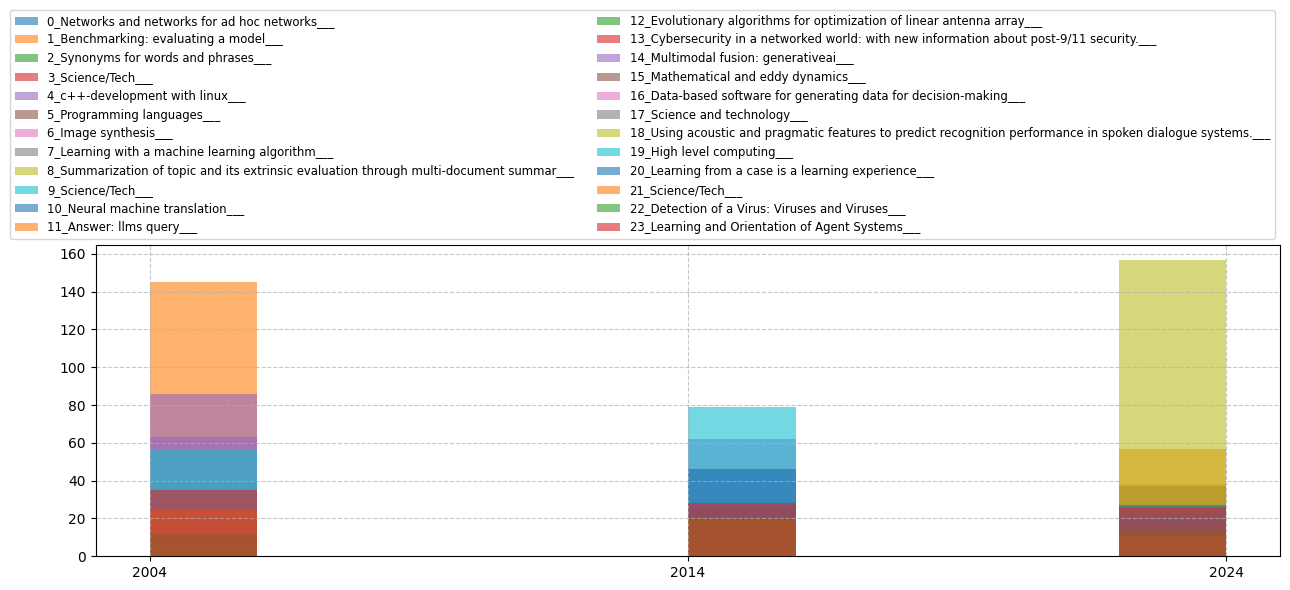

In [227]:

plt.figure(figsize=(14, 6))

for cluster_id in df_without_noise["cluster"].unique():
    subset = df_without_noise[df_without_noise["cluster"] == cluster_id]
    
    cluster_title = subset["Name"].iloc[0] 

    plt.hist(subset["Year"], alpha=0.6, label=str(cluster_title))


plt.grid(True, linestyle='--', alpha=0.7) 
plt.legend(loc='lower right', bbox_to_anchor=(1, 1), ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

Clasters Heatmap

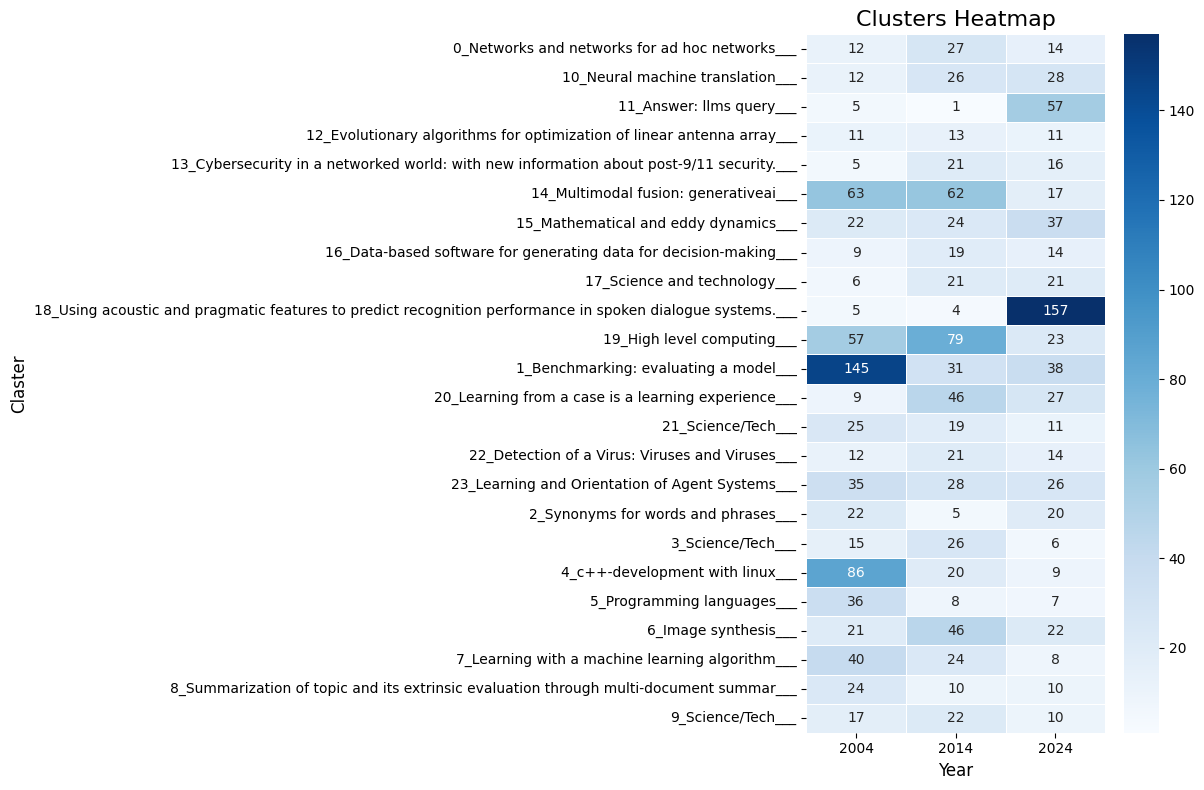

In [219]:
df_counts = df_without_noise.groupby(['Year', 'Name']).size().reset_index(name='count')

pivot_df = df_counts.pivot(index='Name', columns='Year', values='count').fillna(0)

plt.figure(figsize=(12, 8)) 
sns.heatmap(pivot_df, cmap='Blues', annot=True, fmt='g', linewidths=.5)

plt.title('Clusters Heatmap', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Claster', fontsize=12)
plt.tight_layout()
plt.show()

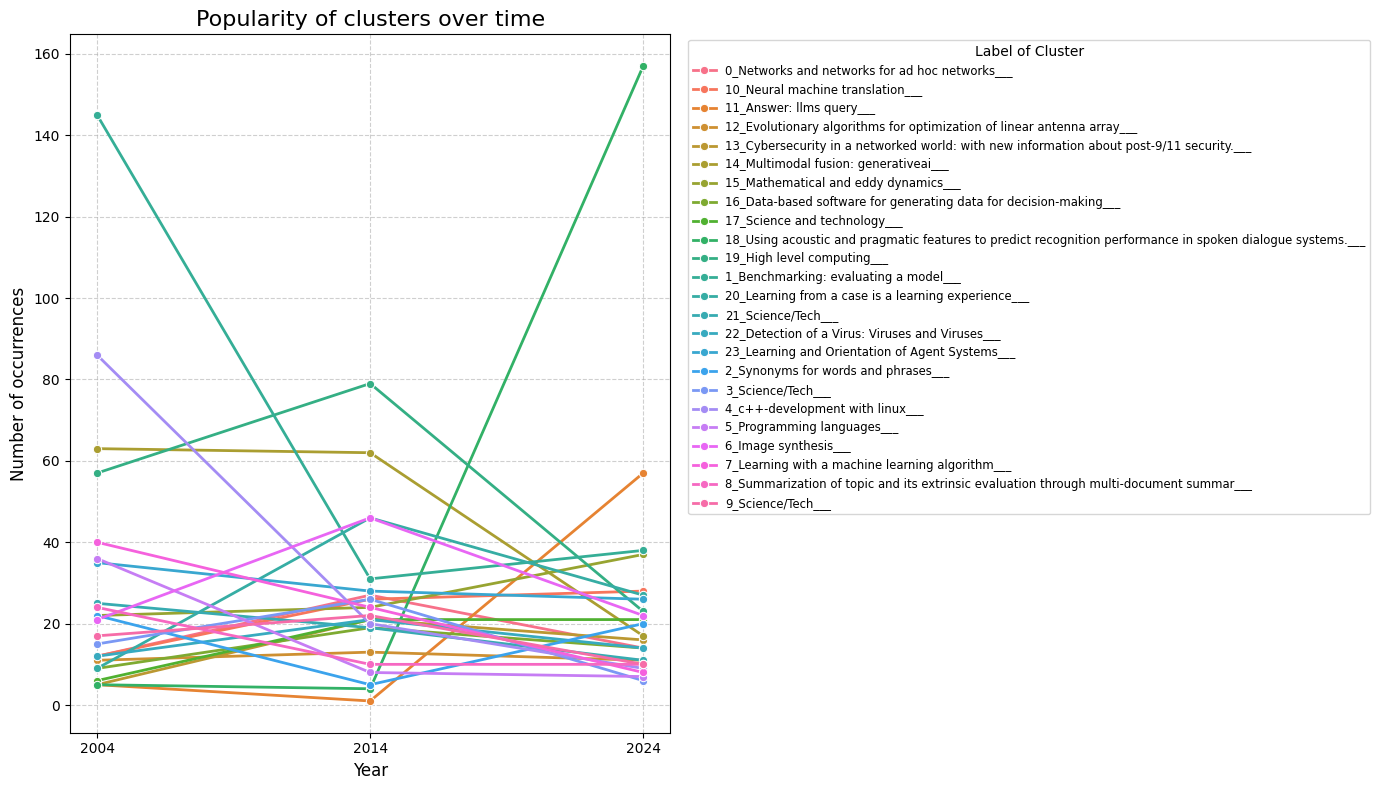

In [220]:

df_counts = df_without_noise.groupby(['Year', 'Name']).size().reset_index(name='count')

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_counts, x='Year', y='count', hue='Name', marker='o', linewidth=2)

plt.title('Popularity of clusters over time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of occurrences', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', title='Label of Cluster')
plt.tight_layout()
plt.show()

## Conclusion